In [ ]:
!git clone https://github.com/instar94/ml_note.git
%cd ml_note

Cloning into 'ml_note'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 67 (delta 18), reused 46 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (67/67), 1.24 MiB | 7.49 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/ml_note/ml_note/ml_note/ml_note/ml_note


In [ ]:
%run env_setup.py

[env_setup] 환경: colab | 한글 폰트 설정 완료


## 1. 데이터셋 준비

### 실습 데이터 소개 (Spaceship Titanic
#### 배경 스토리
> 2912년, 우주선 타이타닉호가 항성간 이동 중 시공간 이상(anomaly) 에 충돌.
> 승객 절반이 다른 차원으로 순간이동(Transported) 되어 사라짐.
> 구조대의 AI로서, 어떤 승객이 순간이동 됐는지 예측하라.

#### 데이터 구조
- 타깃: Transported — True(순간이동 됨) / False(생존)
#### 주요 피처:

| 컬럼 | 설명 | 타입 | 비고 |
|---|---|---|---|
| `PassengerId` | 승객 고유 ID | 문자열 | `그룹번호_개인번호` 형식 (예: `0013_01`) |
| `HomePlanet` | 출발 행성 | 범주형 | Earth / Europa / Mars |
| `CryoSleep` | 냉동수면 여부 | 불리언 | 냉동수면 중 서비스 지출 = 0 |
| `Cabin` | 객실 번호 | 문자열 | `갑판/번호/측면` 형식 (예: `B/0/P`) |
| `Destination` | 목적지 행성 | 범주형 | TRAPPIST-1e / 55 Cancri e / PSO J318.5-22 |
| `Age` | 나이 | 수치형 | |
| `VIP` | VIP 서비스 여부 | 불리언 | |
| `RoomService` | 룸서비스 지출액 | 수치형 | 선내 서비스 지출 5개 중 하나 |
| `FoodCourt` | 푸드코트 지출액 | 수치형 | 선내 서비스 지출 5개 중 하나 |
| `ShoppingMall` | 쇼핑몰 지출액 | 수치형 | 선내 서비스 지출 5개 중 하나 |
| `Spa` | 스파 지출액 | 수치형 | 선내 서비스 지출 5개 중 하나 |
| `VRDeck` | VR 덱 지출액 | 수치형 | 선내 서비스 지출 5개 중 하나 |
| `Name` | 승객 이름 | 문자열 | 성(family name)으로 그룹 추정 가능 |
| `Transported` | 순간이동 여부 | 불리언 | **타깃 변수** (True / False) |

## 2. 데이터셋 불러오기

In [ ]:
import os
import zipfile
#import kaggle
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parents[1]
DATA_DIR = PROJECT_ROOT / "data" / "spaceship-titanic"
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("프로젝트 루트:", PROJECT_ROOT)
print("저장 경로   :", DATA_DIR)

# 다운로드
#kaggle.api.competition_download_files(
#    "spaceship-titanic",
#    path=str(DATA_DIR)
#)

# 압축 해제
#with zipfile.ZipFile(DATA_DIR / "spaceship-titanic.zip", "r") as z:
#    z.extractall(DATA_DIR)

print(os.listdir(DATA_DIR))

프로젝트 루트: /content/ml_note/ml_note/ml_note
저장 경로   : /content/ml_note/ml_note/ml_note/data/spaceship-titanic
['spaceship-titanic.zip', 'sample_submission.csv', 'test.csv', 'train.csv']


In [ ]:
#### 데이터 셋 확인
import pandas as pd
from pathlib import Path


data = pd.read_csv(DATA_DIR / "train.csv")
test_data  = pd.read_csv(DATA_DIR / "test.csv")

print("data shape:", data.shape)
print("test shape :", test_data.shape)
data.head()

data shape: (8693, 14)
test shape : (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 3. EDA - 데이터 분석

### 기본정보 탐색
#### 데이터 정보
- 수치형 : 6
- 문자형 : 5
- 범주형 : 2

#### 타깃 비율
- True : 50.4%
- False : 49.6%

In [ ]:
# 기본 정보
print("-"*10," 기본 정보 " ,"-"*10)
print(data.info())

# 결측값 확인
print("-"*10," 결측값 " ,"-"*10)
print(data.isnull().sum())

----------  기본 정보  ----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None
----------  결측값  ----------
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199

In [ ]:
# 타깃 클래스 비율 확인
print("-"*10," 타깃 비율 " ,"-"*10)
print(data["Transported"].value_counts())
print(data["Transported"].value_counts(normalize=True).round(3))

# 수치형 피처 기초 통계
print("-"*10," 수치형 피처 기초 통계 " ,"-"*10)
data[["Age","RoomService","FoodCourt","ShoppingMall","Spa","VRDeck"]].describe().round(2)

----------  타깃 비율  ----------
Transported
True     4378
False    4315
Name: count, dtype: int64
Transported
True     0.504
False    0.496
Name: proportion, dtype: float64
----------  수치형 피처 기초 통계  ----------


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.00,8512.00,8510.00,8485.00,8510.00,8505.00
mean,28.83,224.69,458.08,173.73,311.14,304.85
std,14.49,666.72,1611.49,604.70,1136.71,1145.72
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,19.00,0.00,0.00,0.00,0.00,0.00
50%,27.00,0.00,0.00,0.00,0.00,0.00
75%,38.00,47.00,76.00,27.00,59.00,46.00
max,79.00,14327.00,29813.00,23492.00,22408.00,24133.00


## 4.데이터 전처리

In [ ]:
print("train shape:", train.shape)
print("test  shape:", test.shape)

train shape: (8693, 14)
test  shape: (4277, 13)


- 타깃(y)와 피쳐(train) 분리
  - sklearn 은 숫자를 기대 -> y 값이 True /False 가아닌 0/1로 구분

In [ ]:

# Transported 컬럼을 y로 분리 후 train에서 제거
y = train["Transported"].astype(int)
train = train.drop(columns=["Transported"])

print("y 샘플:", y[:5].tolist())
print("y shape:", y.shape)
print("train 컬럼 수:", train.shape[1])  # 14 → 13이 되어야 함

y 샘플: [0, 1, 0, 0, 1]
y shape: (8693,)
train 컬럼 수: 13


#### Cabin 값 전처리
- B / 0 / P 처럼 3가지 값이 1개의 컬럼으로 묶임
- 나눠줘야함

In [ ]:
# Cabin 원본값 먼저 확인
print("Cabin 샘플:")
print(train["Cabin"].head())

Cabin 샘플:
0    B/0/P
1    F/0/S
2    A/0/S
3    A/0/S
4    F/1/S
Name: Cabin, dtype: object


In [ ]:

# Cabin 분리
for df in [train, test]:
    df[["Deck", "CabinNum", "Side"]] = df["Cabin"].str.split("/", expand=True)

# 결과 확인
print("분리 결과:")
print(train[["Cabin", "Deck", "CabinNum", "Side"]].head())
print("\nDeck 고유값:", train["Deck"].unique())
print("Side 고유값:", train["Side"].unique())

분리 결과:
   Cabin Deck CabinNum Side
0  B/0/P    B        0    P
1  F/0/S    F        0    S
2  A/0/S    A        0    S
3  A/0/S    A        0    S
4  F/1/S    F        1    S

Deck 고유값: ['B' 'F' 'A' 'G' nan 'E' 'D' 'C' 'T']
Side 고유값: ['P' 'S' nan]


#### 불필요 컬럼 제거
- PassagerID : 단순 구분값
- Name : 단순 구분 +  인코딩 어려움
- Cabin : 이미 Deck/CabinNum/Side로 분리 완료
- CabinNum : 단순 일련번호

In [ ]:
drop_cols = ["PassengerId", "Name", "Cabin", "CabinNum"]

train = train.drop(columns=drop_cols)
test  = test.drop(columns=drop_cols)

# 결과 확인
print("train 컬럼 목록:")
print(train.columns.tolist())
print("\ntrain shape:", train.shape)
print("test  shape:", test.shape)

train 컬럼 목록:
['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Deck', 'Side']

train shape: (8693, 12)
test  shape: (4277, 12)


#### Boolean 처리
- VIP , CryoSleep 는 이미 불리언
- 하지만 nan 이 있음 -> Object로 판단

In [ ]:

bool_cols = ["CryoSleep", "VIP"]

for col in bool_cols:
    for df in [train, test]:
        df[col] = df[col].astype("boolean")

# 결과 확인
print("=== 타입 확인 ===")
print(train[bool_cols].dtypes)

print("\n=== 결측값 확인 ===")
print(train[bool_cols].isnull().sum())

print("\n=== 고유값 확인 ===")
print("CryoSleep:", train["CryoSleep"].unique())
print("VIP      :", train["VIP"].unique())

=== 타입 확인 ===
CryoSleep    boolean
VIP          boolean
dtype: object

=== 결측값 확인 ===
CryoSleep    217
VIP          203
dtype: int64

=== 고유값 확인 ===
CryoSleep: <BooleanArray>
[False, True, <NA>]
Length: 3, dtype: boolean
VIP      : <BooleanArray>
[False, True, <NA>]
Length: 3, dtype: boolean


#### 결측치 처리하기

In [ ]:

print("=== 컬럼별 결측값 현황 ===")
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print("\n전체 결측값:", train.isnull().sum().sum())

=== 컬럼별 결측값 현황 ===
CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Deck            199
Side            199
VRDeck          188
FoodCourt       183
Spa             183
Destination     182
RoomService     181
Age             179
dtype: int64

전체 결측값: 2323


- 전략
  - 수치형 : median
  - 범주형 / bool : mode (최빈값)

In [ ]:
num_cols = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
cat_cols = ["HomePlanet", "Destination", "Deck", "Side"]
bool_cols = ["CryoSleep", "VIP"]

# 수치형 → train의 중앙값으로 채우기
for col in num_cols:
    median = train[col].median()
    train[col] = train[col].fillna(median)
    test[col]  = test[col].fillna(median)

# 범주형 + bool → train의 최빈값으로 채우기
for col in cat_cols + bool_cols:
    mode = train[col].mode().iloc[0]
    train[col] = train[col].fillna(mode)
    test[col]  = test[col].fillna(mode)

# 결과 확인
print("=== 결측값 잔여 (train) ===")
print(train.isnull().sum().sum())

print("\n=== 결측값 잔여 (test) ===")
print(test.isnull().sum().sum())

=== 결측값 잔여 (train) ===
0

=== 결측값 잔여 (test) ===
0


#### 원핫 코딩
- 범주형에 대하여 원핫코딩
- 대상 : "HomePlanet", "Destination", "Deck", "Side"

In [ ]:

encode_cols = ["HomePlanet", "Destination", "Deck", "Side"]

train = pd.get_dummies(train, columns=encode_cols)
test  = pd.get_dummies(test,  columns=encode_cols)

# 결과 확인
print("=== 인코딩 후 컬럼 목록 ===")
print(train.columns.tolist())
print("\ntrain shape:", train.shape)
print("test  shape:", test.shape)

=== 인코딩 후 컬럼 목록 ===
['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Side_P', 'Side_S']

train shape: (8693, 24)
test  shape: (4277, 24)


#### 데이터 최종  확인

In [ ]:

import numpy as np

# bool → float 변환 (CryoSleep, VIP 포함 전체)
X_train = train.astype(float).values
X_test  = test.astype(float).values
y_train = y.values

# 최종 확인
print("=== 최종 shape ===")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)

print("\n=== dtype 확인 ===")
print("X_train dtype:", X_train.dtype)
print("y_train dtype:", y_train.dtype)

print("\n=== NaN 잔여 확인 ===")
print("X_train NaN:", np.isnan(X_train).sum())
print("X_test  NaN:", np.isnan(X_test).sum())

=== 최종 shape ===
X_train: (8693, 24)
X_test : (4277, 24)
y_train: (8693,)

=== dtype 확인 ===
X_train dtype: float64
y_train dtype: int64

=== NaN 잔여 확인 ===
X_train NaN: 0
X_test  NaN: 0


## 이진 분류기 학습

- SGD분류기로 진행
  - 예측 실패

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)

# 훈련 데이터 샘플 1개 예측 확인
print("예측 샘플:", sgd_clf.predict([X_train[0]]))
print("실제 정답:", y_train[0])

예측 샘플: [1]
실제 정답: 0


- 성능 검사

In [ ]:
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    roc_auc_score
)

# 교차 검증 예측 (정확도)
scores = cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")
print("=== 교차 검증 정확도 ===")
print(scores.round(4))
print("평균:", scores.mean().round(4))

# 예측값 생성
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train, cv=3)

# 오차 행렬
cm = confusion_matrix(y_train, y_train_pred)
print("\n=== 오차 행렬 ===")
print(cm)

# 정밀도 / 재현율 / F1
print("\n=== 정밀도 / 재현율 / F1 ===")
print("정밀도:", round(precision_score(y_train, y_train_pred), 4))
print("재현율:", round(recall_score(y_train, y_train_pred), 4))
print("F1    :", round(f1_score(y_train, y_train_pred), 4))

=== 교차 검증 정확도 ===
[0.6708 0.6901 0.7739]
평균: 0.7116

=== 오차 행렬 ===
[[3277 1038]
 [1469 2909]]

=== 정밀도 / 재현율 / F1 ===
정밀도: 0.737
재현율: 0.6645
F1    : 0.6989


예측 False    예측 True
실제 False  [ 3277(TN)     1038(FP) ]
실제 True   [ 1469(FN)     2909(TP) ]

/tmp/ipykernel_11451/3462149851.py:36: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11451/3462149851.py:36: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11451/3462149851.py:36: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11451/3462149851.py:36: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11451/3462149851.py:36: UserWarning: Glyph 48128 (\N{HANGUL SYLLABLE MIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11451/3462149851.py:36: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11451/3462149851.py:36: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt

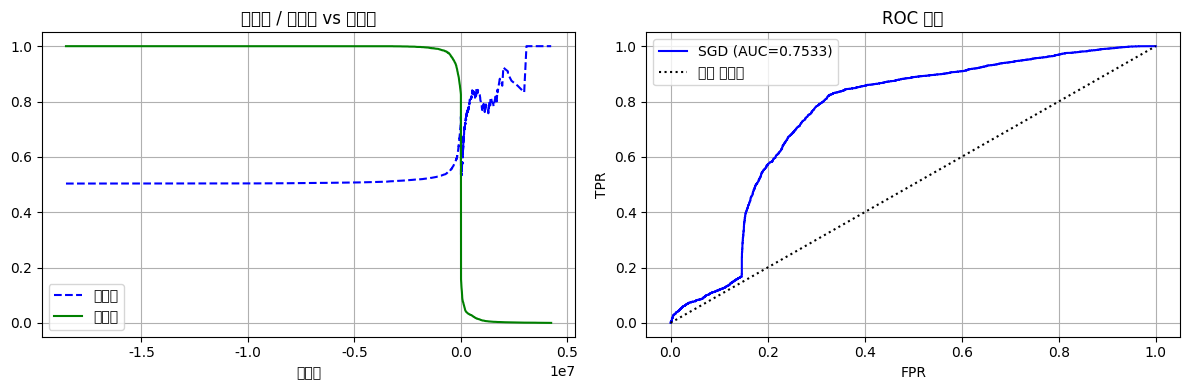

ROC-AUC: 0.7533


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score

# 결정 점수 계산
y_scores = cross_val_predict(
    sgd_clf, X_train, y_train, cv=3, method="decision_function"
)

# PR 곡선
precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

# ROC 곡선
fpr, tpr, roc_thresholds = roc_curve(y_train, y_scores)
auc = roc_auc_score(y_train, y_scores)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽: PR 곡선
axes[0].plot(thresholds, precisions[:-1], "b--", label="정밀도")
axes[0].plot(thresholds, recalls[:-1], "g-", label="재현율")
axes[0].set_xlabel("임계값")
axes[0].set_title("정밀도 / 재현율 vs 임계값")
axes[0].legend()
axes[0].grid()

# 오른쪽: ROC 곡선
axes[1].plot(fpr, tpr, "b-", label=f"SGD (AUC={auc:.4f})")
axes[1].plot([0, 1], [0, 1], "k:", label="랜덤 분류기")
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title("ROC 곡선")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

print("ROC-AUC:", round(auc, 4))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42, n_jobs=-1)

# 예측값 및 확률 점수
y_train_pred_rf = cross_val_predict(rf_clf, X_train, y_train, cv=3)
y_probas_rf     = cross_val_predict(rf_clf, X_train, y_train, cv=3, method="predict_proba")

# 정확도
scores_rf = cross_val_score(rf_clf, X_train, y_train, cv=3, scoring="accuracy")

# 지표 계산
auc_rf = roc_auc_score(y_train, y_probas_rf[:, 1])

print("=== RandomForest 성능 ===")
print("교차 검증 정확도:", scores_rf.round(4))
print("평균 정확도     :", round(scores_rf.mean(), 4))
print("정밀도          :", round(precision_score(y_train, y_train_pred_rf), 4))
print("재현율          :", round(recall_score(y_train, y_train_pred_rf), 4))
print("F1              :", round(f1_score(y_train, y_train_pred_rf), 4))
print("ROC-AUC         :", round(auc_rf, 4))

print("\n=== SGD vs RandomForest 비교 ===")
print(f"{'지표':<12} {'SGD':>8} {'RF':>8}")
print(f"{'정확도':<12} {0.7116:>8.4f} {scores_rf.mean():>8.4f}")
print(f"{'F1':<12} {0.6989:>8.4f} {f1_score(y_train, y_train_pred_rf):>8.4f}")
print(f"{'ROC-AUC':<12} {0.753:>8.4f} {auc_rf:>8.4f}")

=== RandomForest 성능 ===
교차 검증 정확도: [0.7716 0.7847 0.7905]
평균 정확도     : 0.7822
정밀도          : 0.8025
재현율          : 0.7529
F1              : 0.7769
ROC-AUC         : 0.8543

=== SGD vs RandomForest 비교 ===
지표                SGD       RF
정확도            0.7116   0.7822
F1             0.6989   0.7769
ROC-AUC        0.7530   0.8543


In [ ]:
# 전체 train으로 최종 모델 학습 (교차검증 아닌 전체 데이터 사용)
rf_clf_final = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_clf_final.fit(X_train, y_train)

# test 예측
y_pred_test = rf_clf_final.predict(X_test)

# PassengerId 원본에서 다시 로드
test_original = pd.read_csv(DATA_DIR / "test.csv")

# 제출 파일 생성
submission = pd.DataFrame({
    "PassengerId": test_original["PassengerId"],
    "Transported": y_pred_test.astype(bool)  # 1/0 → True/False
})

# 저장
submission_path = DATA_DIR / "submission.csv"
submission.to_csv(submission_path, index=False)

# 확인
print("=== 제출 파일 확인 ===")
print(submission.head(10))
print("\n형태:", submission.shape)
print("Transported 비율:")
print(submission["Transported"].value_counts(normalize=True).round(3))

In [54]:
!pip install kaggle

In [61]:
import os
from google.colab import userdata

# 시크릿에서 불러와 환경변수로 등록
#os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_API_TOKEN"]      = userdata.get("KAGGLE_KEY")

print("KEY 앞 4자리:", os.environ.get("KAGGLE_API_TOKEN")[:4])
# 제출
import kaggle
kaggle.api.authenticate()
kaggle.api.competition_submit(
    file_name=str(submission_path),
    message="RandomForest baseline - 핸즈온ML 3장 실습",
    competition="spaceship-titanic"
)

print("제출 완료!")
print("결과 확인: https://www.kaggle.com/competitions/spaceship-titanic/submissions")

KEY 앞 4자리: KGAT


100%|██████████| 56.5k/56.5k [00:00<00:00, 128kB/s]


제출 완료!
결과 확인: https://www.kaggle.com/competitions/spaceship-titanic/submissions
